# Machine Learning for CICY 4-folds

Following the analysis in [arXiv:2007.13379](http://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](http://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds. The idea is to see whether the Inception network can also be applied in higher dimensions.

## Exploratory Data Analysis

In this notebook we focus on the exploratory data analysis necessary to better understand the composition of the dataset.
We use a complete [dataset](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz.txt) containing engineered features and the labels (i.e. the Hodge numbers).

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from mltools import *

ctx = Context(img_dir='img', log_dir='log', dat_dir='data', session='eda', subdir=False)
log = ctx.logger()

log.info('Exploratory Data Analysis.')

## Read the Dataset

We read the dataset from its [URL](https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz) and display basic information.

In [2]:
tab                  = Table('https://riccardo.rigoletto.dynu.net/datasets/cicy4/cicy4_eng.json.gz', ctx=ctx).read(orient='index')
df, (n_rows, n_cols) = tab.data()
log.debug(f'Dataset: {n_rows:d} rows X {n_cols:d} columns')

No. of rows:    921497.
No. of columns: 31.


As we can see, the dataset is large and takes up a lot of RAM.

In [3]:
df.eda.full_info()

No. of rows:    921497
No. of columns: 31
Index:          <class 'pandas.core.indexes.numeric.Int64Index'>
RAM usage:      779.18 MB.




,dtypes,NA cases,mean,std,0% (min),1%,10%,25%,50% (median),75%,90%,99%,100% (max)
euler,int64,0,334.974098,86.830941,0.000000,0.000000,288.000000,288.000000,318.000000,360.000000,420.000000,636.000000,2610.000000
favour,bool,0,0.535587,0.498732,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
h11,float64,15813,10.065124,2.424114,1.000000,5.000000,7.000000,8.000000,10.000000,12.000000,13.000000,16.000000,24.000000
h21,float64,15813,0.816733,1.882068,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,9.000000,33.000000
h22,float64,15813,240.829490,49.605669,204.000000,204.000000,204.000000,212.000000,226.000000,252.000000,294.000000,440.000000,1752.000000
h31,float64,15813,39.550615,13.719057,20.000000,25.000000,28.000000,31.000000,36.000000,43.000000,55.000000,92.000000,426.000000
isprod,bool,0,0.017160,0.129868,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
matrix,object,0,--,--,--,--,--,--,--,--,--,--,--
size,object,0,--,--,--,--,--,--,--,--,--,--,--
num_cp,int64,0,8.966027,1.782741,1.000000,5.000000,7.000000,8.000000,9.000000,10.000000,11.000000,13.000000,16.000000


We also notice that there are incomplete cases.
They are connected with the configuration matrix being in block diagonal form, i.e. a product space:

In [4]:
df.eda.get_na(columns=['h11', 'h21', 'h31', 'h22']).loc[:, 'isprod'].all()

True

While the complete cases are not product spaces:

In [5]:
df.eda.complete_cases.loc[:, 'isprod'].any()

False

We can therefore discard them:

In [6]:
df = df.eda.complete_cases.drop(columns=['isprod', 'favour'])

## Data Type Conversion

For better representation and handling, we convert a few data types into more sensible dtypes:

In [7]:
df = df.eda.convert_dtype(columns=['h11', 'h21', 'h31', 'h22'], dtype=np.int)

## Distribution of the Labels

Before moving to the data analysis, we take a look at the distribution of the labels and their classes in order to split the dataset with a stratified approach (notice that $h^{2,1}$ vanishes for almost $70\%$ of the cases).
The idea of the exploratory analysis is, in fact, to highlight properties of the data: we keep one "training" set for the hypotheses, and a "test" set to evaluate it.

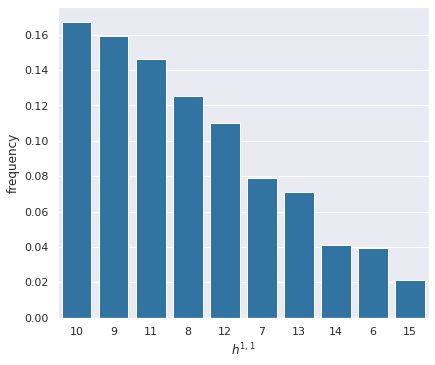

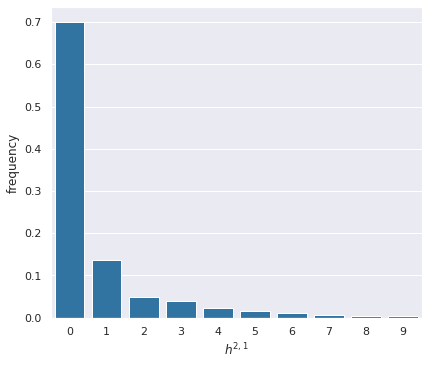

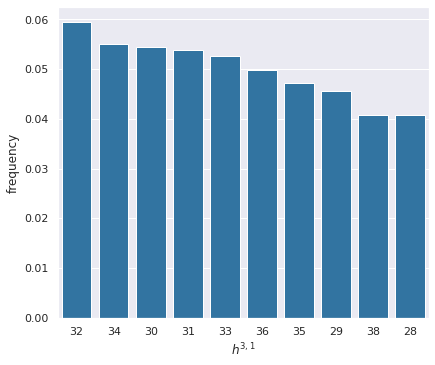

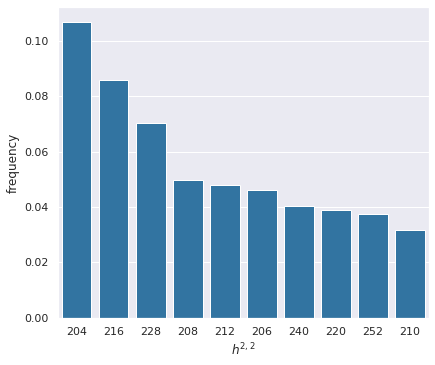

In [8]:
to_tex = lambda s: '${base}^{{ {first}, {second} }}$'.format(base=s[0], first=s[1], second=s[2])

for l in ['h11', 'h21', 'h31', 'h22']:
    
    rank = df.eda.freq_rank(column=l).head(10)
    
    rank.eda.barplot(x='values',
                     y=l,
                     xlabel=to_tex(l),
                     ylabel='frequency',
                     name=l + '_rank',
                     save=True,
                     ctx=ctx
                    )

We then visualise their intervals of definition:

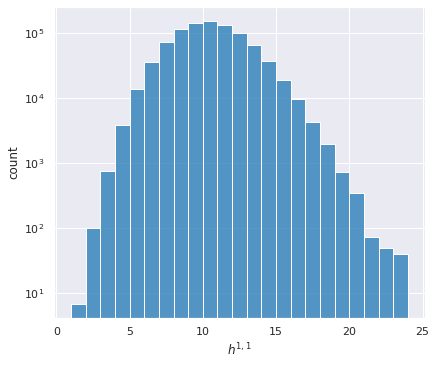

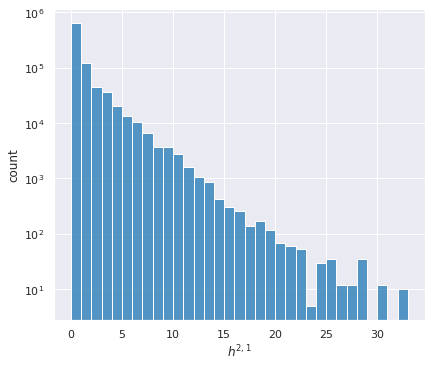

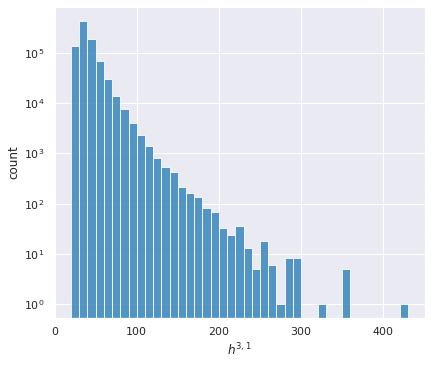

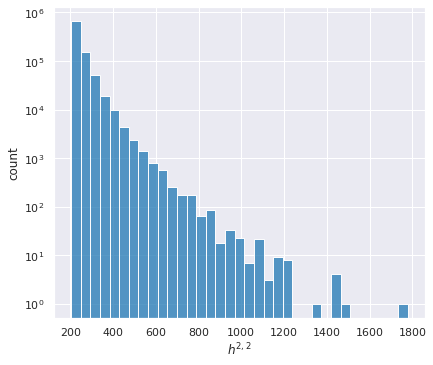

In [9]:
binwidth = {'h11': 1, 'h21': 1, 'h31': 10, 'h22': 45}

for lab, bw in binwidth.items():
    
    df.eda.histplot(series=lab,
                    binwidth=bw,
                    xlabel=to_tex(lab),
                    ylabel='count',
                    logscale=(False,True),
                    save=True,
                    name=lab + '_distrib',
                    ctx=ctx
                   )

As we can see the intervals are very diverse among the labels.
Moreover, $h^{2,1}$ should be considered carefully as it vanishes for almost $70\%$ of the cases.
This suggests a stratified approach.

## Train and Test Splits

We then divide the set into a training and a test set to study correlations and covariances.
The division is stratified on $h^{2,1}$ to avoid difficulties with the unbalanced classes.

In [10]:
train, _, test = df.eda.train_test_split(train=0.8, stratified='h21', random_state=123)
log.info('EDA is performed with a training and a test set divided with stratification over h21.')

Training set:   724547 rows (80.0% ratio)
Test set:        181137 rows (20.0% ratio)


We then plot the full distribution of $h^{2,1}$ against its training and test folds for comparison:

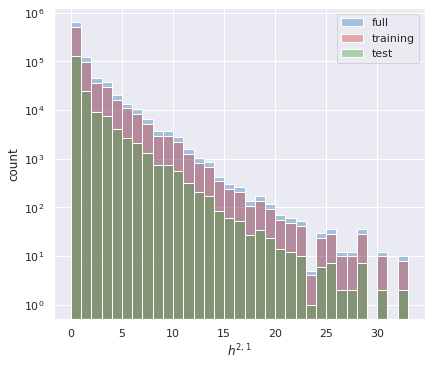

In [11]:
TrainTestPlot(train=df.loc[:, 'h21'],
              validation=train.loc[:, 'h21'],
              test=test.loc[:, 'h21'],
              labels=['full', 'training', 'test']
             ).histplot(xlabel=to_tex('h21'),
                        ylabel='count',
                        binwidth=1,
                        logscale=(False,True),
                        name='stratified_distribution',
                        save=True,
                        alpha=0.35,
                        ctx=ctx
                       )

## Correlations and Covariance

We then plot the correlation matrix of features and labels, and their covariance matrix (standardised).

In [12]:
columns = {'full':     df.select_dtypes(exclude='object').columns.tolist(),
           'features': df.select_dtypes(exclude='object').columns.drop(['h11', 'h21', 'h31', 'h22']).tolist(),
           'labels':   ['h11', 'h21', 'h31', 'h22']
          }

# standardise the full dataset
log.debug('Standardising the dataset...')
train_std = train.loc[:, columns['full']].eda.standardise()
test_std  = test.loc[:, columns['full']].eda.standardise()

# divide features and labels and standardise
X_train, y_train             = train.eda.feat_lab(features=columns['features'], labels=columns['labels'])
(X_mean, X_std), X_train_std = X_train.eda.standardise(return_mean_std=True)
(y_mean, y_std), y_train_std = y_train.eda.standardise(return_mean_std=True)

X_test, y_test               = test.eda.feat_lab(features=columns['features'], labels=columns['labels'])
X_test_std                   = X_test.eda.standardise(mean=X_mean, std=X_std)
y_test_std                   = y_test.eda.standardise(mean=y_mean, std=y_std)

We then compute the correlation matrices:

In [13]:
# correlation and covariance
log.debug('Computing correlations...')
corr = {'train_full': train_std.corr(),
        'train_X':    X_train_std.corr(),
        'train_y':    y_train_std.corr(),
        'test_full':  test_std.corr(),
        'test_X':     X_test_std.corr(),
        'test_y':     y_test_std.corr()
       }

We plot the correlation matrices for the full dataset and the features:

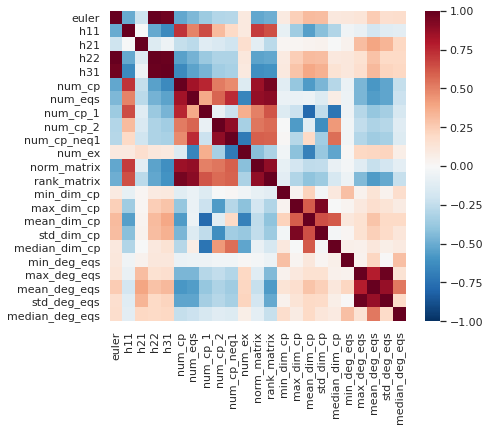

In [14]:
corr['train_full'].eda.heatmap(vmin=-1.0, vmax=1.0, centre=0.0, name='corr_train_full', save=True, ctx=ctx)

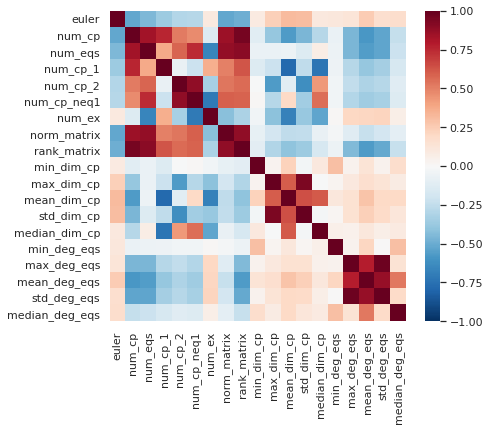

In [15]:
corr['train_X'].eda.heatmap(vmin=-1.0, vmax=1.0, centre=0.0, name='corr_train_X', save=True, ctx=ctx)

As we can see there is a good degree of correlation between the different definition of `num_cp`, and the norm and rank of the matrix.
In fact, we could think of using just one of the definitions for predictions (e.g. `num_cp` and `norm_matrix`).

However we want to test this on the test set of the EDA to be sure.
We compute the difference of the correlation matrices and test how close to $0$ they are:

In [16]:
corr_diff = np.abs(corr['train_X'] - corr['test_X'])

print(f'Maximal difference: {corr_diff.max().max():.3f}')

Maximal difference: 0.049


Moreover the maximal differences for each variable correspond to:

In [17]:
corr_diff.idxmax()

euler             min_deg_eqs
num_cp            num_cp_neq1
num_eqs           max_deg_eqs
num_cp_1          num_cp_neq1
num_cp_2             num_cp_1
num_cp_neq1          num_cp_1
num_ex            min_deg_eqs
norm_matrix       max_deg_eqs
rank_matrix       num_cp_neq1
min_dim_cp        min_deg_eqs
max_dim_cp         min_dim_cp
mean_dim_cp        min_dim_cp
std_dim_cp        mean_dim_cp
median_dim_cp      min_dim_cp
min_deg_eqs        min_dim_cp
max_deg_eqs       norm_matrix
mean_deg_eqs      min_deg_eqs
std_deg_eqs             euler
median_deg_eqs    min_deg_eqs
dtype: object

We can then do the same for the labels:

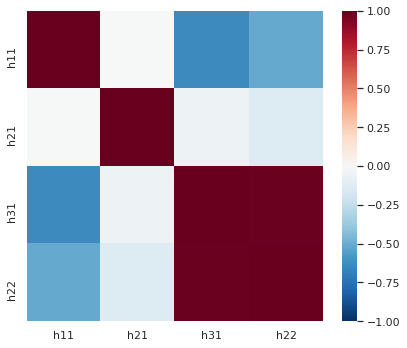

In [18]:
corr['train_y'].eda.heatmap(vmin=-1.0, vmax=1.0, centre=0.0, name='corr_train_y', save=True, ctx=ctx)

The plot shows a strong linear dependence of $h^{3,1}$ and $h^{2,2}$, and a smaller anti-linear dependence between $h^{1,1}$ and $h^{3,1}$.
In turn this can be exploited for the predictions.

We compute the difference to test the hypothesis:

In [19]:
corr_diff = np.abs(corr['train_y'] - corr['test_y'])

print(f'Maximal difference: {corr_diff.max().max():.3f}')

Maximal difference: 0.002


The maximal difference occurs for the following couples of labels:

In [20]:
corr_diff.idxmax()

h11    h31
h21    h22
h31    h11
h22    h21
dtype: object

Notice that in general it seems that the labels and the engineered features are not strongly correlated, exception made for $h^{1,1}$, which is linearly correlated with the number of projective spaces.

The covariance matrix can be used to test a different hypothesis.
We look for its eigenvalues and test whether the matrix contains relevant information or if it needs to be transformed.

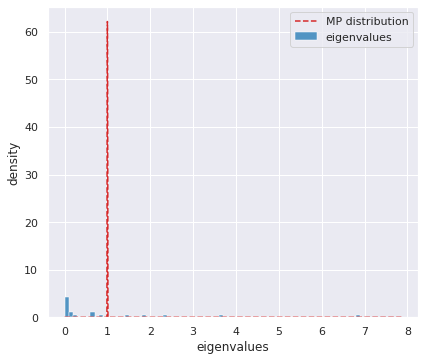

In [21]:
dat = PCAnalysis(X_train_std, standardise=False) # already standardised
dat.distribution(binwidth=0.1, name='mp_distrib_eng_feat', save=True, ctx=ctx)

Unfortunately, the low amount of variables considered does not enable a correct analysis using random matrix theory, which requires a data matrix $X \in \mathbb{R}^{n \times p}$ such that $n, p \to \infty$ and $\frac{p}{n} \to c$.
However, it seems that there may be principal components recovering a pattern.

## Variable Ranking

We consider decision trees trained over the engineered features to rank the variables involved.
We use the [LightGBM](https://github.com/microsoft/LightGBM) algorithm to implement the boosted trees necessary for the extraction of the importance of each feature.
Since the analysis is qualitative at this point, we use only two folds: training and test, previously computed.
We do not use the `euler` variable.

In [22]:
ranker = {lab: VarRank(learning_rate=0.01,
                       num_leaves=50,
                       max_depth=-1,
                       lambda_l1=1.0e-4,
                       lambda_l2=1.0e-3,
                       ctx=ctx
                      ).fit(X_train.drop(columns='euler'),
                            y_train[lab],
                            boost_rounds=7500
                           )
          for lab in ['h11', 'h21', 'h31', 'h22']
         }

In [23]:
ranker_ev = {lab: ranker.evaluate(X_test.drop(columns='euler'),
                                  y_test[lab]
                                 )
             for lab, ranker in ranker.items()
            }
for lab, ev in ranker_ev.items():
    print(f'{lab} --> MSE = {ev:.3f}')

h11 --> MSE = 1.497
h21 --> MSE = 2.526
h31 --> MSE = 83.402
h22 --> MSE = 1337.391


We finally plot the features importances (computed as the no. of times features where used to create a split, normalised to unity):

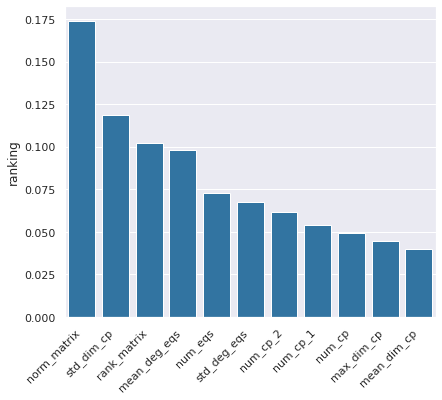

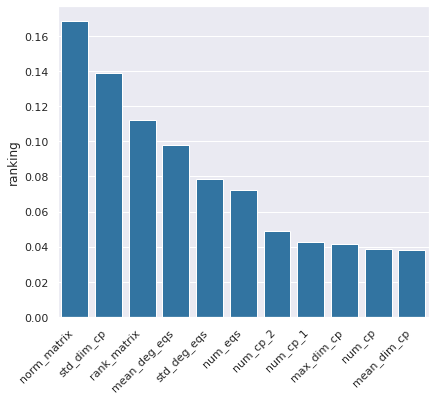

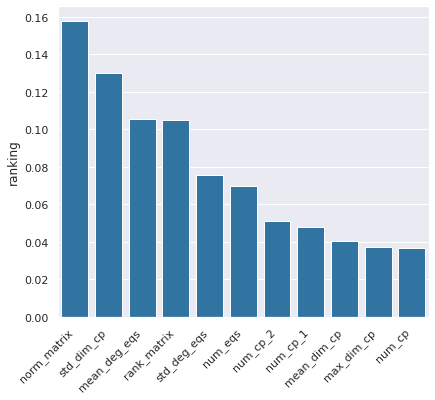

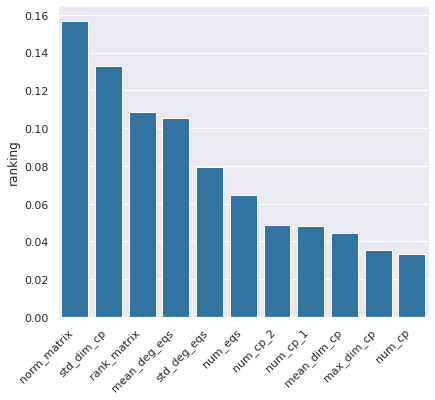

In [24]:
for lab in ['h11', 'h21', 'h31', 'h22']:
    ranker[lab].plot_importance(head=10, name=lab + '_feat_imp', save=True, ctx=ctx)

We can also compare them when ordered as importance for $h^{1,1}$:

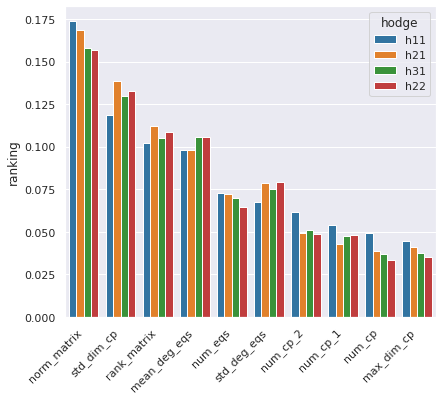

In [25]:
ranker_list  = [ranker[lab].feature_importances() for lab in ranker.keys()]
full_ranking = DFMerge(ranker_list).merge(on='features', suffixes=['_h11', '_h21', '_h31', '_h22'])
full_ranking = full_ranking.rename(columns=lambda c: re.sub('ranking_', '', c))
full_ranking = full_ranking.head(10).melt(id_vars='features', var_name='hodge')

Plot(data=full_ranking,
     ylabel='ranking',
     rotate=45,
     name='feat_imp_comparison',
     save=True,
     ctx=ctx
    ).barplot('features', 'value', 'hodge')

In general it seems that the Hodge numbers are strongly correlated to the norm and the rank of the matrix.